# Lab 1 · EDA and simple baselines
Pairs · 24 September 2026, 12:30 Santiago · 6% NP.
Read the brief and rubric first. Supplied code supports execution; replace the written prompts and add your own analysis cells. MODE="synthetic" is fictional practice only. Real submission uses snapshot.

In [1]:
from pathlib import Path
import sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
for p in (Path.cwd(), *Path.cwd().parents):
    if (p/'labs/lab_01/lab01_support_v1.py').exists():
        ROOT=p; break
else:
    raise FileNotFoundError('Extract the full package and run inside it.')
sys.path.insert(0,str(ROOT/'labs/lab_01'))
from lab01_support_v1 import load_sources,merge_sources,majority_from_train,evaluate
MODE="snapshot"
print('DATA MODE:', MODE, '| Python:',platform.python_version(),'| pandas:',pd.__version__)

DATA MODE: snapshot | Python: 3.14.6 | pandas: 2.3.3


## 1. Target and audit

**Prediction moment:** after qualifying and before the Grand Prix starts.

**Unit:** one driver in one Grand Prix (key: `season + round + driver_id`).

**Population:** every driver/race record in the supplied race-results snapshots. Train (2019–2021) has 1,200 rows from 60 races (21 + 17 + 22), with exactly 20 drivers per race. Retirements, withdrawals, disqualifications and the 3 rows without a qualifying record are kept.

**Target:** `target_top10 = 1` when the numeric final race position is 1–10, otherwise 0. Every race has exactly one driver in each position 1–10, so each race contributes 10 positives and 10 negatives and the train base rate is exactly 50% (600/1,200).

**Final classification is not the same as finishing the race:** the target uses the numeric `position`, which the source assigns to every driver, including those who did not finish. `position_text` keeps the codes: 146 rows are `R` (retired), 6 are `W` (withdrawn) and 3 are `D` (disqualified); all of them have numeric positions between 13 and 20 and are target 0 in train. Examples: Leclerc qualified P1 at the 2021 Monaco Grand Prix but is recorded as withdrawn (`W`, position 20), and Vettel qualified P10 at the 2021 Hungarian Grand Prix but is recorded as disqualified (`D`, position 20). The target is also not "scored points"; it is only the final classification.

**Predictor:** only `qualifying_position` from the qualifying table. `grid`, `position`, `points`, `status` and `laps` come from the results table (post-race information or not approved), so they are used only for audit/EDA.

**Source limitations:**
- Retrospective population: the records come from results retrieved later, not from a verified pre-race entry list.
- The snapshots can contain later corrections (for example disqualifications), so this is not exactly what was known at each historical moment.
- Sprint results are excluded, and qualifying position and the race starting grid need not coincide (see Q3).

In [2]:
q_train,r_train=load_sources('train',ROOT,MODE)
train=merge_sources(q_train,r_train)
display(pd.DataFrame({'qualifying':q_train.groupby('season').size(),'results':r_train.groupby('season').size()}))
display(train.groupby('season').agg(rows=('driver_id','size'),missing_qualifying=('qualifying_position',lambda x:x.isna().sum())))
assert len(train)==len(r_train)
display(train['qualifying_match'].value_counts())

,qualifying,results
season,,
2019,418,420
2020,340,340
2021,439,440


,rows,missing_qualifying
season,,
2019,420,2
2020,340,0
2021,440,1


qualifying_match
both          1197
left_only        3
right_only       0
Name: count, dtype: int64

### Join audit
The supplied helper performs a left join from results to qualifying on `season + round + driver_id`. The cells below check full-row duplicates, duplicate keys, qualifying-only records, missing values, coverage by season, the meaning of `position_text`, and what an inner join would change.

In [3]:
duplicates = train.duplicated().sum()
null_cols = train.columns[train.isna().any()]
count_rows = train.shape[0]

print(f"Number of duplicate rows: {duplicates}")
print(f"Columns with missing values: {null_cols.tolist()}")
print(f"Total number of rows in the dataset: {count_rows}")

Number of duplicate rows: 0
Columns with missing values: ['qualifying_position']
Total number of rows in the dataset: 1200


In [4]:
## Audit: key uniqueness, qualifying-only records, missingness and coverage (train only)
keys = ['season', 'round', 'driver_id']
print('Duplicate keys in results:', r_train.duplicated(keys).sum())
print('Duplicate keys in qualifying:', q_train.duplicated(keys).sum())

## qualifying rows with no matching result would be invisible in a left join from results
quali_only = q_train.merge(r_train[keys], on=keys, how='left', indicator=True)
print('Qualifying-only records (no matching result):', (quali_only['_merge'] == 'left_only').sum())

## coverage by season: races, rows, missing qualifying and top-ten rows
coverage = (train.groupby('season')
                 .agg(races=('round', 'nunique'), rows=('driver_id', 'size'),
                      missing_qualifying=('qualifying_position', lambda x: x.isna().sum()),
                      top10_rows=('target_top10', 'sum')))
display(coverage)
drivers_per_race = train.groupby(['season', 'round']).size()
print('Drivers per race (min/max):', drivers_per_race.min(), drivers_per_race.max())

## the 3 rows without a qualifying record
display(train.loc[train['qualifying_position'].isna(),
                  ['season', 'round', 'race_name', 'driver_id', 'grid', 'position', 'status', 'target_top10']])

## final classification vs finishing: non-numeric position_text codes (R, W, D) still get a numeric position
pos_code = train['position_text'].astype(str)
pos_code = pos_code.where(~pos_code.str.isdigit(), 'numeric')
display(pd.crosstab(pos_code, train['target_top10'], rownames=['position_text'], colnames=['target_top10']))

## what an inner join would do to the evaluated population
inner = train[train['qualifying_match'] == 'both']
print(f"Left join rows: {len(train)} | inner join rows: {len(inner)}")
print(f"Target rate left: {train['target_top10'].mean():.4f} | inner: {inner['target_top10'].mean():.4f}")
print(f"Training majority left: {majority_from_train(train)} | inner: {majority_from_train(inner)}")

Duplicate keys in results: 0
Duplicate keys in qualifying: 0
Qualifying-only records (no matching result): 0


,races,rows,missing_qualifying,top10_rows
season,,,,
2019,21,420,2,210
2020,17,340,0,170
2021,22,440,1,220


Drivers per race (min/max): 20 20


,season,round,race_name,driver_id,grid,position,status,target_top10
49,2019,3,Chinese Grand Prix,albon,0,10,+1 Lap,1
54,2019,3,Chinese Grand Prix,giovinazzi,19,15,+1 Lap,0
857,2021,5,Monaco Grand Prix,mick_schumacher,20,18,+3 Laps,0


target_top10,0,1
position_text,,
D,3,0
R,146,0
W,6,0
numeric,445,600


Left join rows: 1200 | inner join rows: 1197
Target rate left: 0.5000 | inner: 0.5004
Training majority left: 0 | inner: 1


**Audit results (train):**
- **Keys:** 0 duplicate keys in results, 0 in qualifying and 0 fully duplicated rows after the join. `merge_sources` also validates the join as one-to-one.
- **Coverage:** results have 420 / 340 / 440 rows for 2019 / 2020 / 2021 (21 / 17 / 22 races × 20 drivers); qualifying has 418 / 340 / 439. Every race has exactly 20 drivers and exactly 10 top-ten rows.
- **Qualifying-only records:** 0. Every qualifying row matches a result.
- **Missing values:** only `qualifying_position` has missing values: 3 rows (0.25%) with no qualifying record. They are Albon and Giovinazzi at the 2019 Chinese Grand Prix (round 3) and Mick Schumacher at the 2021 Monaco Grand Prix (round 5). Albon started from the pit lane (grid 0) and finished P10, so one of the three is a positive.
- **Inner join:** it would silently drop those 3 rows (1,200 → 1,197). The dropped rows are not neutral for the target: 1 positive and 2 negatives are removed, so the target rate moves from 50.00% to 50.04% and the training majority flips from 0 to 1 (see Q2). The evaluated population would no longer be "all race results", and the missing-qualifying fallback could never be exercised.
- **Decision:** keep the left join and all 1,200 rows; rows with missing qualifying use the training-majority fallback (0). An earlier version of this notebook dropped these rows; that was corrected because the brief requires keeping them (documented in section 5).

## 2. EDA question 1
Question: How well does qualifying position anticipate a top-ten finish?

Use train only. Add a table/graph, cite observed values, interpret and state a decision or limitation. At least one of the three analyses must check a Friday trap.

,Drivers,Finished top 10,Top-10 rate
Qualifying position,,,
1,60,57,95.0%
2,60,52,86.7%
3,60,50,83.3%
4,60,52,86.7%
5,60,44,73.3%
6,60,45,75.0%
7,60,43,71.7%
8,60,34,56.7%
9,60,40,66.7%


Rows without qualifying (excluded from this table): 3


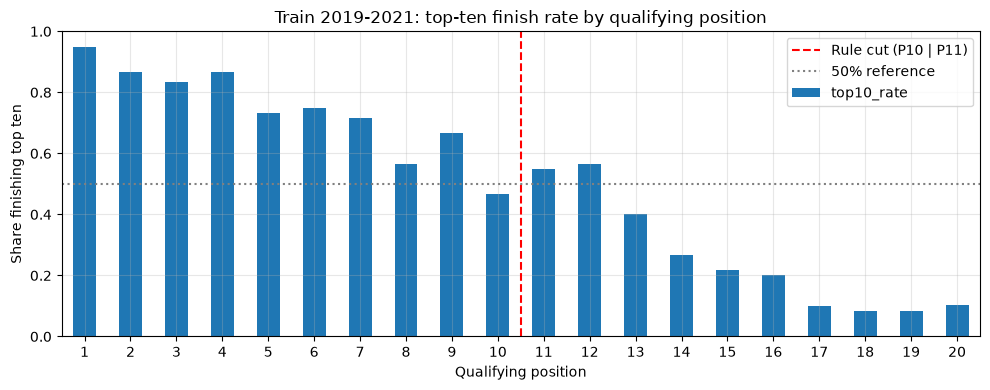

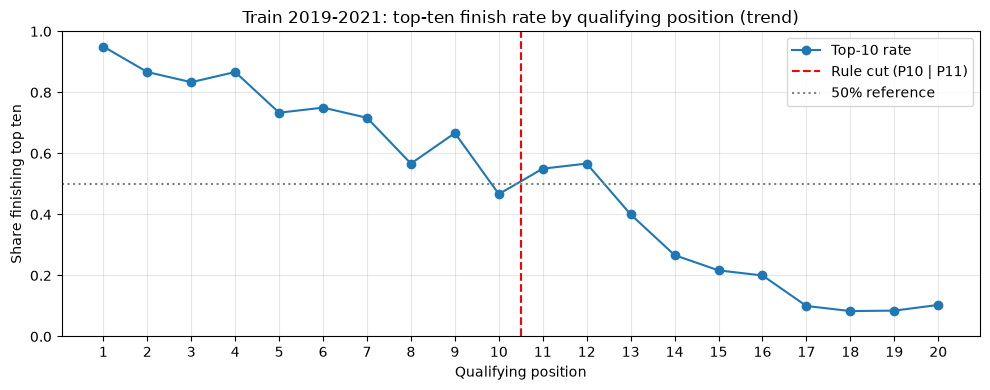

In [5]:
## Q1: top-ten rate for each qualifying position (train 2019-2021 only)
stats_q1 = (train
            .groupby('qualifying_position')['target_top10']
            .agg(drivers='count', finished_top10='sum', top10_rate='mean'))
stats_q1.index = stats_q1.index.astype(int)

## readable copy for display only, the numeric one stays for the chart
table_q1 = stats_q1.copy()
table_q1.index.name = 'Qualifying position'
table_q1['top10_rate'] = (table_q1['top10_rate'] * 100).round(1).astype(str) + '%'
table_q1.columns = ['Drivers', 'Finished top 10', 'Top-10 rate']
display(table_q1)

## groupby drops NaN keys, so the 3 rows without qualifying are NOT in this table
n_missing_quali = train['qualifying_position'].isna().sum()
print(f"Rows without qualifying (excluded from this table): {n_missing_quali}")

## bar chart: y fixed 0-1 so the drop isn't exaggerated, dashed line = the rule's cut
fig, ax = plt.subplots(figsize=(10, 4))
stats_q1['top10_rate'].plot(kind='bar', ax=ax, color='#1f77b4')
ax.axvline(9.5, color='red', linestyle='--', label='Rule cut (P10 | P11)')
ax.axhline(0.5, color='gray', linestyle=':', label='50% reference')
ax.set_ylim(0, 1)
ax.set_xlabel('Qualifying position')
ax.set_ylabel('Share finishing top ten')
ax.set_title('Train 2019-2021: top-ten finish rate by qualifying position')
ax.tick_params(axis='x', rotation=0)  ## keeps position labels horizontal
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## line chart: same data, easier to see the overall trend across positions
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(stats_q1.index, stats_q1['top10_rate'], marker='o', color='#1f77b4', label='Top-10 rate')
ax.axvline(10.5, color='red', linestyle='--', label='Rule cut (P10 | P11)')
ax.axhline(0.5, color='gray', linestyle=':', label='50% reference')
ax.set_xticks(stats_q1.index)  ## show every position 1-20 on the x-axis
ax.set_ylim(0, 1)
ax.set_xlabel('Qualifying position')
ax.set_ylabel('Share finishing top ten')
ax.set_title('Train 2019-2021: top-ten finish rate by qualifying position (trend)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation (Q1)

**Observed values (train, 1,197 rows with a qualifying record):**
- The top-ten rate falls as qualifying position gets worse: P1 95.0% (57/60), P1–P3 88.3% (159/180), P18–P20 9.0% (16/177).
- Qualifying P1–P10: 445 of 600 drivers (74.2%) finished top ten. Qualifying P11–P20: 154 of 597 (25.8%).
- There is **no clean step at P10**. P8–P12 together sit just above the 50% line (169/300 = 56.3%), and the order is not even monotonic there: P10 is 46.7% (28/60), below P11 at 55.0% (33/60) and P12 at 56.7% (34/60).
- Each position has 60 drivers, except P19 (59) and P20 (58): the races with a missing qualifying record have no P19/P20 entry, and `groupby` leaves the 3 NaN rows out of the table (they are reported separately). With n = 60, one driver moves a rate by about 1.7 percentage points, so small differences between neighbouring positions are noise.

**Graphical framing check:** both charts fix the y-axis at 0–1 and show the 50% reference, so a truncated axis does not exaggerate the decline. The bar chart makes the cut look like a step; the line chart shows that the trend is gradual.

**Consequence for the prediction:** qualifying position carries clear signal (74.2% vs 25.8%), so the qualifying rule should beat the 50% majority. However, the fixed cut at 10 falls inside a zone where outcomes are close to a coin flip, so we expect most errors to come from P8–P10 qualifiers who finish outside the top ten (false positives) and P11–P13 qualifiers who finish inside it (false negatives). The threshold stays at 10 as the brief requires; we do not tune it.

## 3. EDA question 2
Question: Does the training majority change if the rows with missing qualifying positions are dropped?

Use train only. Add a table/graph, cite observed values, interpret and state a decision or limitation. At least one of the three analyses must check a Friday trap.

In [6]:
# First search missing columns in the train dataset
missing_columns_train = train.columns[train.isna().any()].tolist()
print(f"Missing columns in train dataset: {missing_columns_train}")
#Next, we see how many missing values are in the qualifying_position column
missing_qualifying_position = train['qualifying_position'].isna().sum()
print(f"Number of missing values in 'qualifying_position' column: {missing_qualifying_position}")
overall_null_percentage = train.isna().to_numpy().mean() * 100
print(f"Overall percentage of null cells in the entire dataset: {overall_null_percentage:.2f}%")

# Create a filtered copy; keep the original train dataset unchanged
train_without_missing = train[
    train["qualifying_position"].notna()
].copy()

# Compare both populations
comparison = pd.DataFrame({
    "dataset": [
        "All train rows",
        "Missing qualifying rows dropped"
    ],
    "number_of_rows": [
        len(train),
        len(train_without_missing)
    ],
    "missing_qualifying": [
        train["qualifying_position"].isna().sum(),
        train_without_missing["qualifying_position"].isna().sum()
    ],
    "target_top10_rate": [
        train["target_top10"].mean(),
        train_without_missing["target_top10"].mean()
    ],
    "training_majority": [
        majority_from_train(train),
        majority_from_train(train_without_missing)
    ]
})

comparison["target_top10_rate"] = (
    comparison["target_top10_rate"] * 100
).round(2)

display(comparison)



Missing columns in train dataset: ['qualifying_position']
Number of missing values in 'qualifying_position' column: 3
Overall percentage of null cells in the entire dataset: 0.01%


,dataset,number_of_rows,missing_qualifying,target_top10_rate,training_majority
0,All train rows,1200,3,50.00,0
1,Missing qualifying rows dropped,1197,0,50.04,1


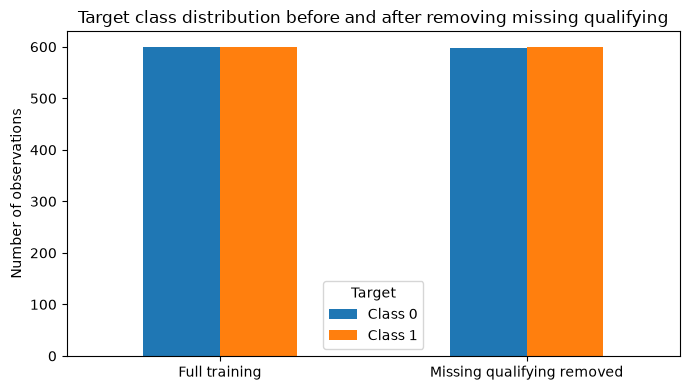

In [7]:
# Compare class distribution before and after removing missing qualifying positions

class_comparison = pd.DataFrame({
    "Class 0": [
        (train["target_top10"] == 0).sum(),
        (train_without_missing["target_top10"] == 0).sum()
    ],
    "Class 1": [
        (train["target_top10"] == 1).sum(),
        (train_without_missing["target_top10"] == 1).sum()
    ]
}, index=["Full training", "Missing qualifying removed"])

ax = class_comparison.plot(
    kind="bar",
    figsize=(7, 4)
)

ax.set_xlabel("")
ax.set_ylabel("Number of observations")
ax.set_title("Target class distribution before and after removing missing qualifying")
ax.legend(title="Target")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation (Q2) · Selection trap check

**Observed values:**
- Full train: 1,200 rows, 600 class 0 and 600 class 1 (target rate 50.00%). This is an exact tie, so by the baseline definition the training majority is **0**.
- After dropping the 3 rows with missing qualifying: 1,197 rows, 598 class 0 and 599 class 1 (target rate 50.04%). The training majority **changes to 1**.
- The 3 dropped rows are not neutral: 1 is a positive (Albon, 2019 Chinese Grand Prix, pit-lane start, finished P10) and 2 are negatives (Giovinazzi, P15; Mick Schumacher, P18). Their top-ten rate is 1/3, but with only 3 rows this should not be generalised.

**Why such a small filter matters:** every race has exactly 10 top-ten finishers out of 20 drivers, so the base rate sits exactly at 50%. At a tie, removing one more negative than positive flips the majority. The target rate barely moves (+0.04 percentage points), but the baseline decision changes completely: the majority rule would switch from predicting 0 for every row to predicting 1 for every row.

**Trap:** this is a selection trap. A filter that looks harmless ("drop rows with missing values", or an inner join) changes the population and, with it, the baseline.

**Decision:** we keep all 1,200 rows, as the brief requires, and use the training-majority fallback (0) for missing qualifying. Our first version of the notebook made exactly this mistake; section 5 documents the correction.

## 4. EDA question 3
Question: Are Grid and Qualifying position the same number? Do they match?

Use train only. Add a table/graph, cite observed values, interpret and state a decision or limitation. At least one of the three analyses must check a Friday trap.

,Rows,Grid = qualifying,Grid != qualifying,Pit-lane starts (grid 0),Cross the P10 cut
Train 2019-2021,1197,816,381,28,53


Grid top 10,False,True
Qualifying top 10,,
False,571,26
True,27,573


,,drivers,finished_top10
quali_top10,grid_top10,,
False,True,26,18
True,False,27,9


,season,round,driver_id,qualifying_position,grid,position,status
37,2019,2,ricciardo,11.0,10,18,Out of fuel
39,2019,2,grosjean,8.0,11,20,Retired
71,2019,4,giovinazzi,8.0,17,12,+1 Lap
79,2019,4,ricciardo,11.0,10,20,Collision
91,2019,5,ricciardo,10.0,13,12,Finished
99,2019,5,norris,11.0,10,20,Collision
124,2019,7,max_verstappen,11.0,9,5,Finished
129,2019,7,kvyat,12.0,10,10,+1 Lap
130,2019,7,sainz,9.0,11,11,+1 Lap
136,2019,7,kevin_magnussen,10.0,0,17,+2 Laps


Correlation qualifying vs grid: 0.87


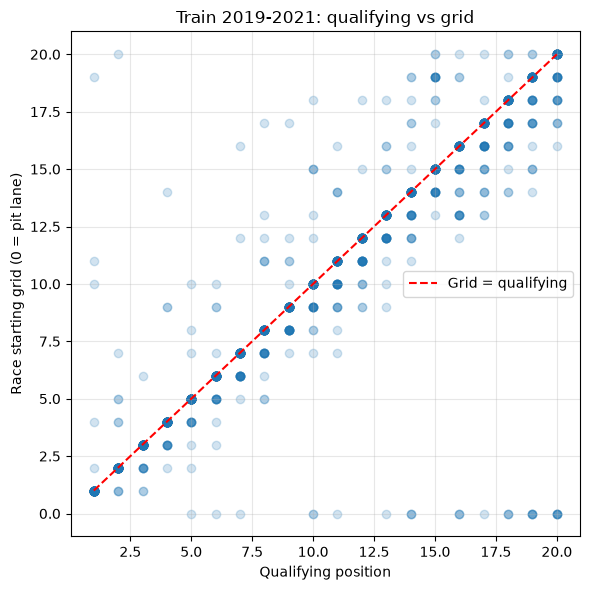

In [8]:
## Q3: does the race starting grid match qualifying position? (train only, EDA)
## only rows with a qualifying record, the 3 NaN rows can't be compared
has_quali = train.dropna(subset=['qualifying_position']).copy()

has_quali['same_position'] = has_quali['grid'] == has_quali['qualifying_position']
has_quali['pit_lane_start'] = has_quali['grid'] == 0  ## grid 0 = started from the pit lane

## side of the P10 cut for each source (grid 0 counts as outside the top ten)
has_quali['quali_top10'] = has_quali['qualifying_position'] <= 10
has_quali['grid_top10'] = has_quali['grid'].between(1, 10)
has_quali['crosses_cut'] = has_quali['quali_top10'] != has_quali['grid_top10']

summary_q3 = pd.DataFrame({
    'Rows'                     : [len(has_quali)],
    'Grid = qualifying'        : [has_quali['same_position'].sum()],
    'Grid != qualifying'       : [(~has_quali['same_position']).sum()],
    'Pit-lane starts (grid 0)' : [has_quali['pit_lane_start'].sum()],
    'Cross the P10 cut'        : [has_quali['crosses_cut'].sum()],
}, index=['Train 2019-2021'])
display(summary_q3)

## which side of the cut each driver was on, by qualifying vs by grid
table_cut = pd.crosstab(has_quali['quali_top10'], has_quali['grid_top10'],
                        rownames=['Qualifying top 10'], colnames=['Grid top 10'])
display(table_cut)

## for the rows that cross the cut: what actually happened in the race?
crossers = has_quali[has_quali['crosses_cut']]
table_crossers = (crossers
                  .groupby(['quali_top10', 'grid_top10'])['target_top10']
                  .agg(drivers='count', finished_top10='sum'))
display(table_crossers)

## a few concrete cases to cite in the interpretation
display(crossers[['season', 'round', 'driver_id', 'qualifying_position',
                  'grid', 'position', 'status']].head(10))

## Q3 chart: qualifying position vs race grid
corr = has_quali['qualifying_position'].corr(has_quali['grid'])
print(f"Correlation qualifying vs grid: {corr:.2f}")

plt.figure(figsize=(6, 6))
plt.scatter(has_quali['qualifying_position'], has_quali['grid'], alpha=0.2)
plt.plot([1, 20], [1, 20], color='red', linestyle='--', label='Grid = qualifying')
plt.xlabel('Qualifying position')
plt.ylabel('Race starting grid (0 = pit lane)')
plt.title('Train 2019-2021: qualifying vs grid')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation (Q3) · Misleading correlation check

**Observed values (train, 1,197 rows with a qualifying record):**
- Grid equals qualifying position in 816 rows (68.2%) and differs in 381 (31.8%).
- 28 of these drivers started from the pit lane (`grid = 0`); a 29th pit-lane start (Albon, 2019 Chinese Grand Prix) has no qualifying record.
- 53 rows (4.4%) fall on different sides of the P10 cut: 27 qualified top ten but started outside it (9 of them finished top ten), and 26 qualified outside but started inside it (18 of them finished top ten).
- The correlation between qualifying position and grid is high (0.87).

**Trap check (misleading correlation and framing):** a correlation of 0.87 suggests the two variables are almost interchangeable, but it hides the 53 rows that cross the cut, which is exactly where the qualifying rule is decided. In addition, `grid = 0` is plotted at the bottom of the scatter as if it were the front of the grid, when a pit-lane start is actually the back.

**Consequence for the prediction:** we keep qualifying position as the only predictor and do not use grid. `grid` comes from the results table, is not an approved predictor, and can include changes made after qualifying (penalties, pit-lane starts); the records can also include later corrections. Using it would move the prediction moment. The cost is visible: some of the rule's errors near P10 come from drivers whose starting position changed after qualifying. A possible next step is to study whether grid changes known before the race could be used legitimately at a later prediction moment.

## 5. Baselines and 2022 check

**Rules (fixed by the brief, not tuned):**
- **Training majority:** predict the most frequent target in train 2019–2021 for every row. Train has exactly 600/1200 positives (50.0%), an exact tie, so by rule the majority is **0**. It is computed once on train and never recomputed on 2022 or test.
- **Qualifying top ten:** predict 1 if `qualifying_position ≤ 10`, else 0. If qualifying is missing, fall back to the training majority (0). Train has 3 such rows; calibration 2022 has **0**, so the fallback is not used in the check.

**Why the majority is still useful:** it is the "no information" reference. Any rule that uses qualifying must beat it to show that qualifying carries signal.

**Expected failures (written before running the check):**
- *Majority:* since each race has exactly 10 top-ten finishers out of 20 (Q2), predicting all 0 should give ~50% accuracy and 50% balanced accuracy, no better than a coin flip.
- *Qualifying top ten:* Q1 shows the top-ten rate does not jump at P10. It falls gradually, and P8–P12 sit around 50%. We expect most errors near the cut: false positives from P8–P10 qualifiers who drop back or retire, and false negatives from P11–P13 qualifiers who recover. 2022 also introduced new technical regulations, so the relationship might be weaker than in train.

In [9]:
majority=majority_from_train(train)
print('Training majority:',majority,'| training target rate:',train.target_top10.mean())
q_cal,r_cal=load_sources('calibration',ROOT,MODE)
cal=merge_sources(q_cal,r_cal)
print('Calibration rows:',len(cal),'| missing qualifying:',cal.qualifying_position.isna().sum())
display(evaluate(cal,majority))

Training majority: 0 | training target rate: 0.5
Calibration rows: 440 | missing qualifying: 0


,n,TN,FP,FN,TP,accuracy,balanced_accuracy
majority,440.0,220.0,0.0,220.0,0.0,0.500000,0.500000
qualifying_top10,440.0,168.0,52.0,52.0,168.0,0.763636,0.763636


In [10]:
## 2022 check: where do the qualifying rule's errors come from?
from lab01_support_v1 import baseline_predictions

cal_check = cal.copy()
cal_check['pred_quali'] = baseline_predictions(cal_check, majority)['qualifying_top10']
cal_check['error_type'] = 'correct'
cal_check.loc[(cal_check['pred_quali'] == 1) & (cal_check['target_top10'] == 0), 'error_type'] = 'FP'
cal_check.loc[(cal_check['pred_quali'] == 0) & (cal_check['target_top10'] == 1), 'error_type'] = 'FN'

## every race has 10 real top-ten finishers and 10 predicted ones, so FP should equal FN per race
per_race = cal_check.groupby('round')['error_type'].value_counts().unstack(fill_value=0)
print('Races where FP == FN:', (per_race['FP'] == per_race['FN']).sum(), 'of', len(per_race))

## where on the grid the errors happen
bands = pd.cut(cal_check['qualifying_position'], bins=[0, 7, 10, 13, 20],
               labels=['P1-7', 'P8-10', 'P11-13', 'P14-20'])
display(pd.crosstab(bands, cal_check['error_type']))

## why the false positives happened: classified finish vs retirement (status = EDA context only)
fp = cal_check[cal_check['error_type'] == 'FP']
classified = fp['status'].str.match(r'^(Finished|\+\d+ Laps?)$')
display(pd.Series({'FP still classified (finished / lapped)': classified.sum(),
                   'FP retired (crash, mechanical...)': (~classified).sum()},
                  name='2022 false positives'))

Races where FP == FN: 22 of 22


error_type,FN,FP,correct
qualifying_position,,,
P1-7,0,22,132
P8-10,0,30,36
P11-13,24,0,42
P14-20,28,0,126


FP still classified (finished / lapped)    16
FP retired (crash, mechanical...)          36
Name: 2022 false positives, dtype: int64

**2022 calibration results (440 rows, 22 races, 0 missing qualifying):**

| Rule | TN | FP | FN | TP | Accuracy | Balanced acc. |
|---|---:|---:|---:|---:|---:|---:|
| Majority (0) | 220 | 0 | 220 | 0 | 0.500 | 0.500 |
| Qualifying top ten | 168 | 52 | 52 | 168 | 0.764 | 0.764 |

**Reading the matrix:**
- **TP (168):** qualified top ten and finished top ten. **TN (168):** qualified outside and finished outside.
- **FP (52):** qualified top ten but finished outside. **FN (52):** qualified outside but finished inside.
- The majority predicts 0 for everyone: it gets every negative right (TN = 220) and misses every positive (FN = 220). Its accuracy of 0.50 is exactly the base rate, so it has no discriminative skill.
- The qualifying rule reaches **0.764**, i.e. 26 points above the reference, so qualifying carries real signal.

**Why accuracy = balanced accuracy here:** each race has exactly 10 top-ten finishers and, with no missing qualifying, exactly 10 predicted positives. Every FP therefore forces an FN in the same race; FP = FN in all 22 races. The classes are perfectly balanced, so both metrics coincide.

**Where the errors are:** 30 of 52 FP come from P8–P10 and 24 of 52 FN from P11–P13, confirming the border-zone expectation from Q1. Of the 52 FP, **36 retired** (collisions, power unit, engine…) and only 16 finished outside the top ten on pace. Most false positives are race incidents that are not knowable after qualifying.

**Error costs (no monetary values):** an FP means trusting a driver who then fails to score. It overstates front-runners and is mostly driven by unpredictable retirements. An FN means ignoring a midfield driver who recovers into the top ten. In this task both errors are equally frequent by construction, so neither rule can trade one for the other without changing the fixed threshold, which we do not do.

**Corrections after the check:** our first run had a `dropna` on `qualifying_position` (against the brief). That made the training majority **1** (599/1197), and the 2022 majority baseline predicted all 1 (FP = 220). We removed the `dropna`, kept the 3 rows, and re-ran: the majority became **0** (commit `d04b02b`). No threshold, fallback or feature was changed after seeing 2022.

## 6. Freeze before final test
Complete this record and commit the code before enabling RUN_TEST.

- **Members and date:** Andy Villarroel, Agustín Reyes · 23 September 2026.
- **Target, population, join and prediction moment:** target = 1 if the numeric final race position is 1–10, else 0 (final classification, not finishing or scoring points). Unit = one driver in one Grand Prix. Population = all driver/race records in the supplied results snapshots, including retirements and rows without qualifying. Join = left join from results to qualifying on `season + round + driver_id`. Prediction moment = after qualifying, before the race.
- **Baselines, train majority, threshold and missing policy:** training majority = **0** (600/1200, exact tie → 0), computed once on 2019–2021. Qualifying rule: predict 1 if `qualifying_position ≤ 10`. Missing qualifying → fallback to majority (0); rows are never dropped. Only `qualifying_position` is used as a predictor; `grid`, `position`, `points`, `status` and `laps` are EDA/audit only.
- **Three analysis decisions and changes after calibration:** Q1 → the top-ten rate declines gradually with no step at P10, so errors are expected near the cut. Q2 → dropping the 3 missing-qualifying rows flips the majority from 0 to 1, so all rows are kept. Q3 → grid differs from qualifying in 381/1197 rows and 53 cross the P10 cut, but grid is not used (results-table information, not approved). Change after calibration: none to the method; the only correction (removing `dropna`) is documented in section 5.
- **Frozen code commit/version:** `c38a1f9` (committed with `RUN_TEST=False`; test opened afterwards).

The test switch is a learning aid. Accessing CSVs directly still counts as inspecting test. Do not change the method in response to test results. Document genuine later bug fixes transparently.

In [11]:
RUN_TEST=True
if RUN_TEST:
    q_test,r_test=load_sources('test',ROOT,MODE,frozen=True)
    test=merge_sources(q_test,r_test)
    print('Test rows:',len(test),'| missing qualifying:',test.qualifying_position.isna().sum())
    display(evaluate(test,majority))
else:
    print('Test remains unopened by this notebook. Complete and commit the freeze record first.')

Test rows: 919 | missing qualifying: 0


,n,TN,FP,FN,TP,accuracy,balanced_accuracy
majority,919.0,459.0,0.0,460.0,0.0,0.499456,0.500000
qualifying_top10,919.0,365.0,94.0,93.0,367.0,0.796518,0.796517


In [12]:
## post-freeze description of the test errors (no rule, threshold or fallback was changed)
test_check = test.copy()
test_check['pred_quali'] = baseline_predictions(test_check, majority)['qualifying_top10']
test_check['error_type'] = 'correct'
test_check.loc[(test_check['pred_quali'] == 1) & (test_check['target_top10'] == 0), 'error_type'] = 'FP'
test_check.loc[(test_check['pred_quali'] == 0) & (test_check['target_top10'] == 1), 'error_type'] = 'FN'

## races and drivers per race in the test population
print('Races per season:', test.groupby('season')['round'].nunique().to_dict())
print('Drivers per race:', test.groupby(['season', 'round']).size().value_counts().to_dict())

## qualifying rule by season
display(pd.DataFrame({s: evaluate(test[test['season'] == s], majority).loc['qualifying_top10']
                      for s in sorted(test['season'].unique())}).T)

## where on the grid the errors happen
bands = pd.cut(test_check['qualifying_position'], bins=[0, 7, 10, 13, 20],
               labels=['P1-7', 'P8-10', 'P11-13', 'P14-20'])
display(pd.crosstab(bands, test_check['error_type']))

## false positives: classified finish vs retirement (status = descriptive context only)
fp = test_check[test_check['error_type'] == 'FP']
classified = fp['status'].str.match(r'^(Finished|\+\d+ Laps?)$')
display(pd.Series({'FP still classified (finished / lapped)': classified.sum(),
                   'FP retired (crash, mechanical...)': (~classified).sum()},
                  name='2023-2024 false positives'))

Races per season: {2023: 22, 2024: 24}
Drivers per race: {20: 45, 19: 1}


,n,TN,FP,FN,TP,accuracy,balanced_accuracy
2023,440.0,163.0,57.0,57.0,163.0,0.740909,0.740909
2024,479.0,202.0,37.0,36.0,204.0,0.847599,0.847594


error_type,FN,FP,correct
qualifying_position,,,
P1-7,0,42,280
P8-10,0,52,87
P11-13,48,0,90
P14-20,45,0,275


FP still classified (finished / lapped)    31
FP retired (crash, mechanical...)          63
Name: 2023-2024 false positives, dtype: int64

## 7. Final interpretation and handoff

**Calibration vs test (rules frozen in commit `c38a1f9` before opening test):**

| Rule | 2022 accuracy | 2022 bal. acc. | 2023–24 accuracy | 2023–24 bal. acc. |
|---|---:|---:|---:|---:|
| Majority (0) | 0.500 | 0.500 | 0.499 | 0.500 |
| Qualifying top ten | 0.764 | 0.764 | 0.797 | 0.797 |

Test confusion matrix, qualifying top ten: TN 365, FP 94, FN 93, TP 367.

**Test population:** 919 rows from 46 races (22 in 2023, 24 in 2024), 460 positives and 459 negatives. Every race has 20 rows except the 2024 Australian Grand Prix, which has 19 in the source. That is why FP (94) and FN (93) differ by one and the majority accuracy is 0.499 instead of exactly 0.500. Missing qualifying: 0 rows, so the fallback was used 0 times in test (and 0 times in 2022); it was only exercised in train (3 rows).

**What the evidence supports:** the qualifying top-ten rule beats the trivial majority in both periods (0.764 vs 0.500 in 2022; 0.797 vs 0.500 in 2023–24). Qualifying position carries real information about the final classification, and the result held on unseen seasons without any change to the method. The majority stays at about 0.50 because each race has exactly 10 top-ten finishers, so it is only a reference point. The test score is not uniform: 0.741 in 2023 and 0.848 in 2024. Season-to-season variation is therefore larger than the gap between calibration and test, and a single season should not be over-interpreted.

**Failure mode:** the rule fails in the border zone around P10, the same pattern seen in 2022. In test, 52 of 94 FP came from P8–P10 qualifiers and 48 of 93 FN from P11–P13 qualifiers. 63 of the 94 FP were retirements (collisions, mechanical failures…), i.e. race incidents that cannot be known after qualifying. A hard cut at 10 cannot capture incidents, reliability, grid changes after qualifying (Q3) or recovery drives.

**Limitations:**
- *Retrospective population:* rows come from race results retrieved later, not from a verified pre-race entry list (e.g. the 2024 Australian Grand Prix has 19 rows).
- *Source timing:* snapshots can contain later corrections (penalties, disqualifications), so this is not exactly what was known at each historical moment.
- *Missing qualifying:* the fallback predicts 0 by rule, whatever the driver's actual pace. It was never exercised in calibration or test, so its behaviour on unseen data is untested.
- *Baseline structure:* with exactly 10 positives per race, accuracy and balanced accuracy almost coincide, and the majority baseline is a coin flip by construction.

**Next steps:** (1) investigate retirements, since most false positives were not predictable from qualifying; (2) study whether grid changes known before the race could be used legitimately at a later prediction moment; (3) examine why 2023 and 2024 differ (e.g. how competitive the midfield was around P10).

Complete RUNBOOK and PROMPTS/contributions; restart/run all and save outputs. Submit the repository URL and final commit via Canvas. No separate report is required.